# Muscule Fatigue Problem

# Install the right Kernel

In [26]:
## You have to execute this command on the terminal: pip install ipykernel. Then select this kernel for this file on your IDE. 

import sys
print(sys.executable)

/home/simonsloan/Universidad/Semestre5/InteligenciaArtificial/Report2ArtificialInteligence/venv/bin/python


## Import some libreries

In [ ]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy
from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


## Load dataset

In [28]:
dataset = load_dataset("YominE/Muscle_Fatigue_Cycling")

## We got to understand how data comes

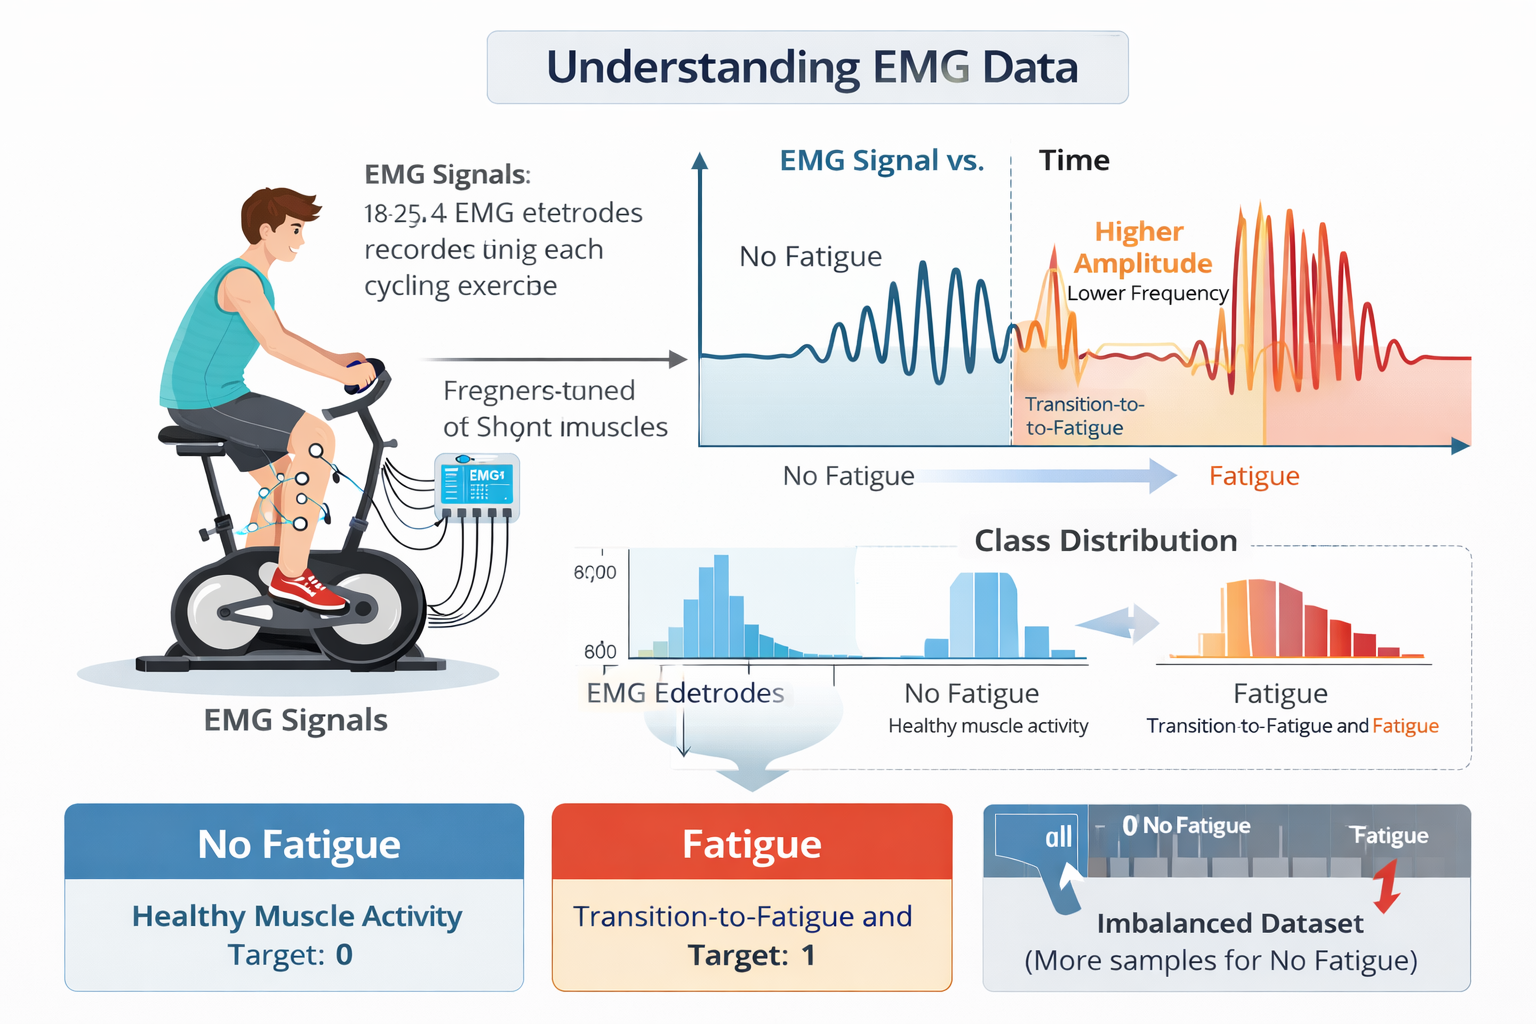

3002137

In [29]:
df = dataset["train"].to_pandas()
img = Image.open("images/UnderstandingData.png")
display(img)
df.head()
len(df)

## Preliminary analysis

In [30]:

df["Target"] = df["Target"].replace(2, 1)

X = df.drop(columns=["Target"])
y = df["Target"]

# As all X data is numeric, then we could skip this pass. But we do it for good practices

numerical_cols = X.select_dtypes(include='number').columns.tolist()

## Feature Engineering. Create Windows

In [31]:
window_size = 1000
overlap = 500
step = window_size - overlap  

windows = []

for start in range(0, len(df) - window_size + 1, step):
    end = start + window_size
    window = df.iloc[start:end]
    windows.append(window)

len(windows)


6003

## Feature Engenieering. Get features 

### Define functions for getting our metrics

- Root Mean Square -> Muscular Energy 
- Mean Absolute Value -> Average intensity
- VAR -> Variability
- Waveform -> Signal Complexity
- Zero Crossing -> Frecuency Changes 
- Median Frecuency -> Spectral Shift
- Mean Frecuency -> Mean Frecuency Energy


In [32]:
def get_rms(signal):
    
    squared_signal = signal ** 2
    mean_squared = np.mean(squared_signal)
    rms_value = np.sqrt(mean_squared)

    return rms_value

def get_mav(signal):

    absolute_signal = np.abs(signal)
    mav_value = np.mean(absolute_signal)

    return mav_value

def get_variance(signal):

    variance_value = np.var(signal)

    return variance_value

def get_waveform_length(signal):

    consecutive_differences = np.diff(signal)
    absolute_differences = np.abs(consecutive_differences)
    waveform_length = np.sum(absolute_differences)

    return waveform_length

def get_zero_crossings(signal):

    signal_sign = np.sign(signal)
    sign_changes = np.diff(signal_sign)
    zero_crossings = np.sum(sign_changes != 0)

    return zero_crossings

def get_mean_frequency(signal, sampling_rate):

    frequencies = np.fft.rfftfreq(len(signal), d=1 / sampling_rate)

    spectrum = np.fft.rfft(signal)
    power_spectrum = np.abs(spectrum) ** 2

    weighted_sum = np.sum(frequencies * power_spectrum)
    total_power = np.sum(power_spectrum)

    mean_frequency = weighted_sum / total_power

    return mean_frequency

def get_median_frequency(signal, sampling_rate):

    spectrum = np.fft.rfft(signal)
    power_spectrum = np.abs(spectrum) ** 2

    frequencies = np.fft.rfftfreq(len(signal), d=1 / sampling_rate)

    cumulative_power = np.cumsum(power_spectrum)
    half_power = cumulative_power[-1] / 2

    median_index = np.where(cumulative_power >= half_power)[0][0]
    median_frequency = frequencies[median_index]

    return median_frequency

### Single function to get all new features for a channel

In [33]:
def extract_emg_features(signal, sampling_rate):

    features = {}

    features["RMS"] = get_rms(signal)
    features["MAV"] = get_mav(signal)
    features["VAR"] = get_variance(signal)
    features["WL"] = get_waveform_length(signal)
    features["ZC"] = get_zero_crossings(signal)
    features["MNF"] = get_mean_frequency(signal, sampling_rate)
    features["MDF"] = get_median_frequency(signal, sampling_rate)

    return features

### Create new features 

In [34]:
emg_cols = df.drop(columns=["Time", "Target"]).columns

feature_rows = []

for window in windows:

    row = {}

    for col in emg_cols:

        signal = window[col].values

        features = extract_emg_features(signal, window_size)

        for name, value in features.items():
            row[f"{name}_{col}"] = value

    
    row["Target"] = window["Target"].mode()[0]

    feature_rows.append(row)



### Analize new dataset

In [35]:
features_df = pd.DataFrame(feature_rows)
features_df.tail()

,RMS_Right Rectus femoris,MAV_Right Rectus femoris,VAR_Right Rectus femoris,WL_Right Rectus femoris,ZC_Right Rectus femoris,MNF_Right Rectus femoris,MDF_Right Rectus femoris,RMS_Left Gluteus maximus,MAV_Left Gluteus maximus,VAR_Left Gluteus maximus,...,MNF_Right Tibialis anterior,MDF_Right Tibialis anterior,RMS_Left Gastrocnemius lateralis,MAV_Left Gastrocnemius lateralis,VAR_Left Gastrocnemius lateralis,WL_Left Gastrocnemius lateralis,ZC_Left Gastrocnemius lateralis,MNF_Left Gastrocnemius lateralis,MDF_Left Gastrocnemius lateralis,Target
5998,0.012759,0.008528,0.000163,3.077093,116,50.208926,38.0,0.019298,0.013296,0.000372,...,49.792734,46.0,0.014673,0.009532,0.000215,4.586481,167,69.155793,63.0,1
5999,0.117980,0.066026,0.013919,24.856174,114,58.438502,58.0,0.014399,0.009696,0.000207,...,45.646660,45.0,0.065036,0.039129,0.004230,23.199399,171,92.068977,90.0,1
6000,0.148649,0.111157,0.022095,42.910323,121,57.750744,58.0,0.015890,0.011738,0.000252,...,39.484665,33.0,0.089267,0.068435,0.007969,42.816314,190,94.988660,97.0,1
6001,0.097579,0.066249,0.009522,25.171762,124,58.762047,54.0,0.024502,0.019278,0.000600,...,38.957454,33.0,0.064810,0.044482,0.004200,26.392927,162,96.433249,98.0,1
6002,0.035826,0.019044,0.001282,6.319464,122,46.257715,38.0,0.024074,0.017781,0.000579,...,44.705995,39.0,0.019106,0.012975,0.000365,6.203379,165,71.627614,70.0,1


## Exploratory Data Analysis

### Descriptive statistics

In [36]:
features_df.describe()

,RMS_Right Rectus femoris,MAV_Right Rectus femoris,VAR_Right Rectus femoris,WL_Right Rectus femoris,ZC_Right Rectus femoris,MNF_Right Rectus femoris,MDF_Right Rectus femoris,RMS_Left Gluteus maximus,MAV_Left Gluteus maximus,VAR_Left Gluteus maximus,...,MNF_Right Tibialis anterior,MDF_Right Tibialis anterior,RMS_Left Gastrocnemius lateralis,MAV_Left Gastrocnemius lateralis,VAR_Left Gastrocnemius lateralis,WL_Left Gastrocnemius lateralis,ZC_Left Gastrocnemius lateralis,MNF_Left Gastrocnemius lateralis,MDF_Left Gastrocnemius lateralis,Target
count,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,...,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000
mean,0.035728,0.022599,0.001869,8.169663,108.871564,54.278352,47.496752,0.011703,0.008064,0.000452,...,70.974069,66.166750,0.051142,0.033777,0.003513,15.488103,136.690655,71.596486,66.422455,0.291188
std,0.024343,0.015184,0.003586,5.447796,13.130379,5.801281,7.748748,0.017755,0.012352,0.002464,...,15.047498,17.180356,0.029961,0.021418,0.004390,9.374307,21.481339,11.890292,16.160313,0.454348
min,0.002933,0.001999,0.000009,0.860550,62.000000,20.728963,16.000000,0.002799,0.002164,0.000008,...,34.108052,20.000000,0.002876,0.002030,0.000008,1.054256,51.000000,24.788843,12.000000,0.000000
25%,0.021407,0.013369,0.000458,4.986161,100.000000,51.205574,43.000000,0.005372,0.004024,0.000029,...,65.365294,57.000000,0.029585,0.019241,0.000875,9.197407,124.000000,67.818378,62.000000,0.000000
50%,0.030134,0.018657,0.000908,6.853139,109.000000,54.754134,48.000000,0.006998,0.004993,0.000049,...,72.136532,66.000000,0.043339,0.027566,0.001878,12.937129,134.000000,72.740254,69.000000,0.000000
75%,0.042171,0.026971,0.001778,9.527208,118.000000,57.994858,53.000000,0.010827,0.007371,0.000117,...,79.662170,76.000000,0.066444,0.043580,0.004415,20.227267,147.500000,77.709300,75.000000,1.000000
max,0.205966,0.134972,0.042422,47.269924,155.000000,70.831706,74.000000,0.206078,0.148809,0.042468,...,109.391545,120.000000,0.197308,0.151165,0.038928,82.863903,214.000000,108.854792,116.000000,1.000000


### Define style for grafics

In [37]:
sns.set_style("whitegrid")
sns.set_context("talk")

### Graphics (Histograms)

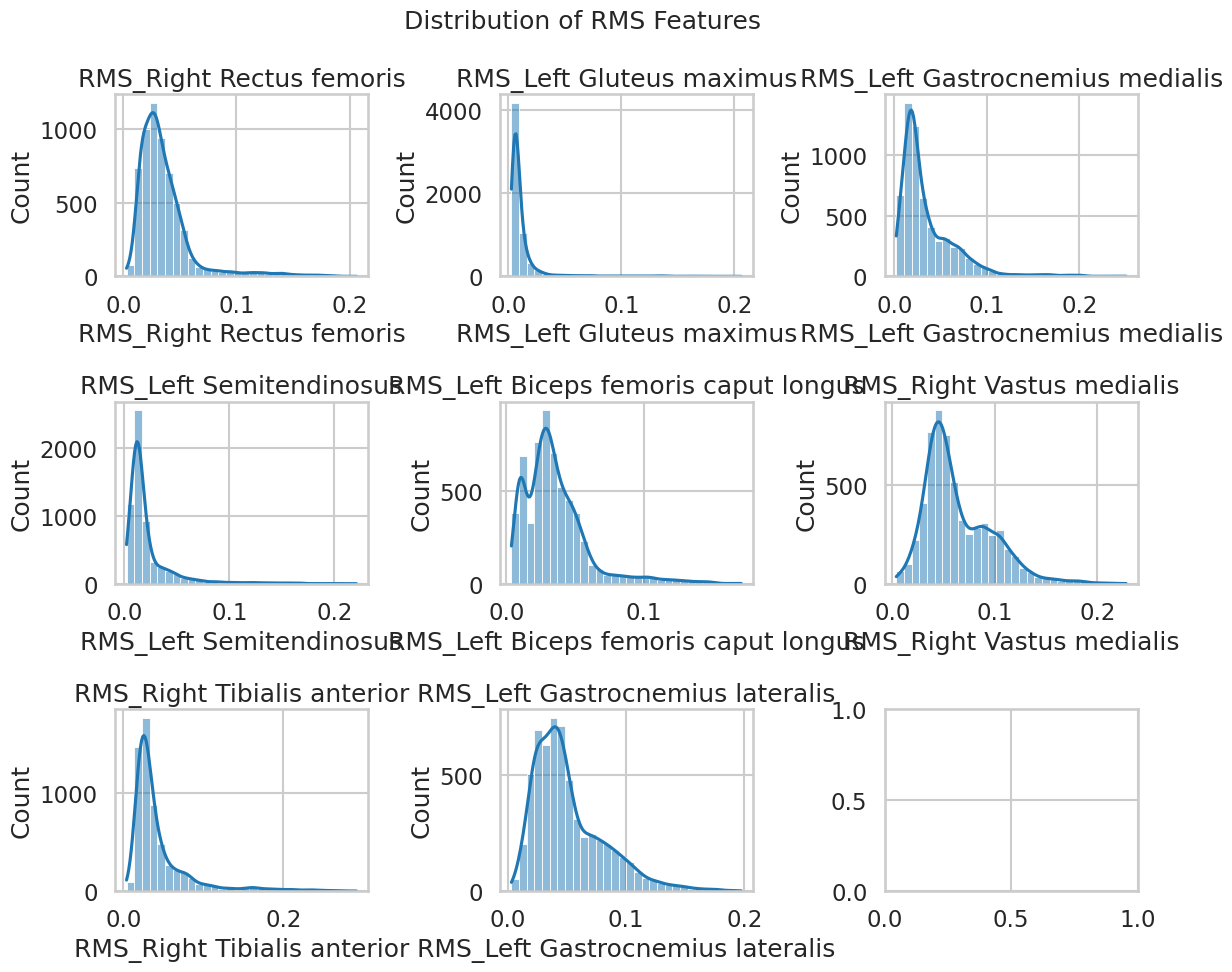

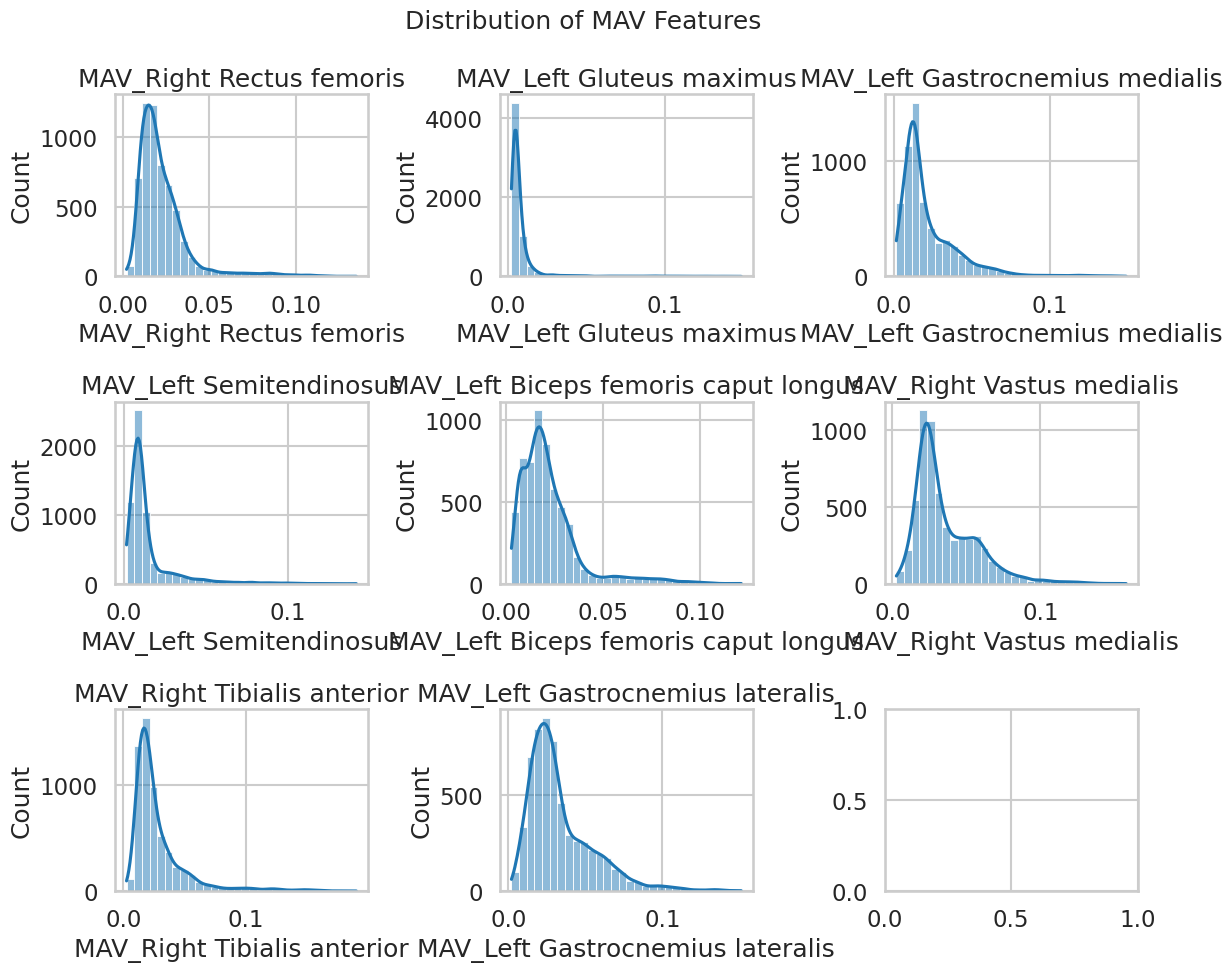

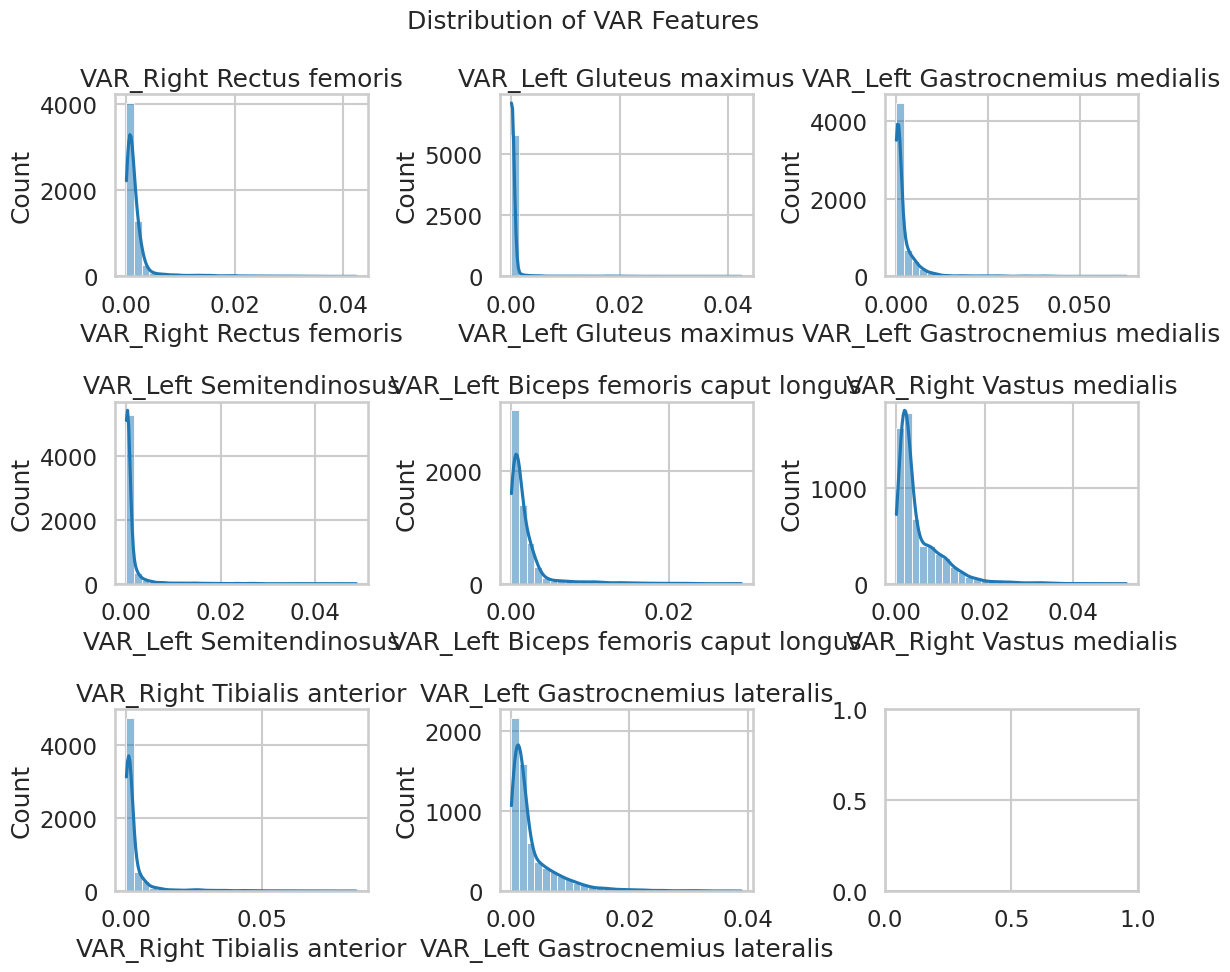

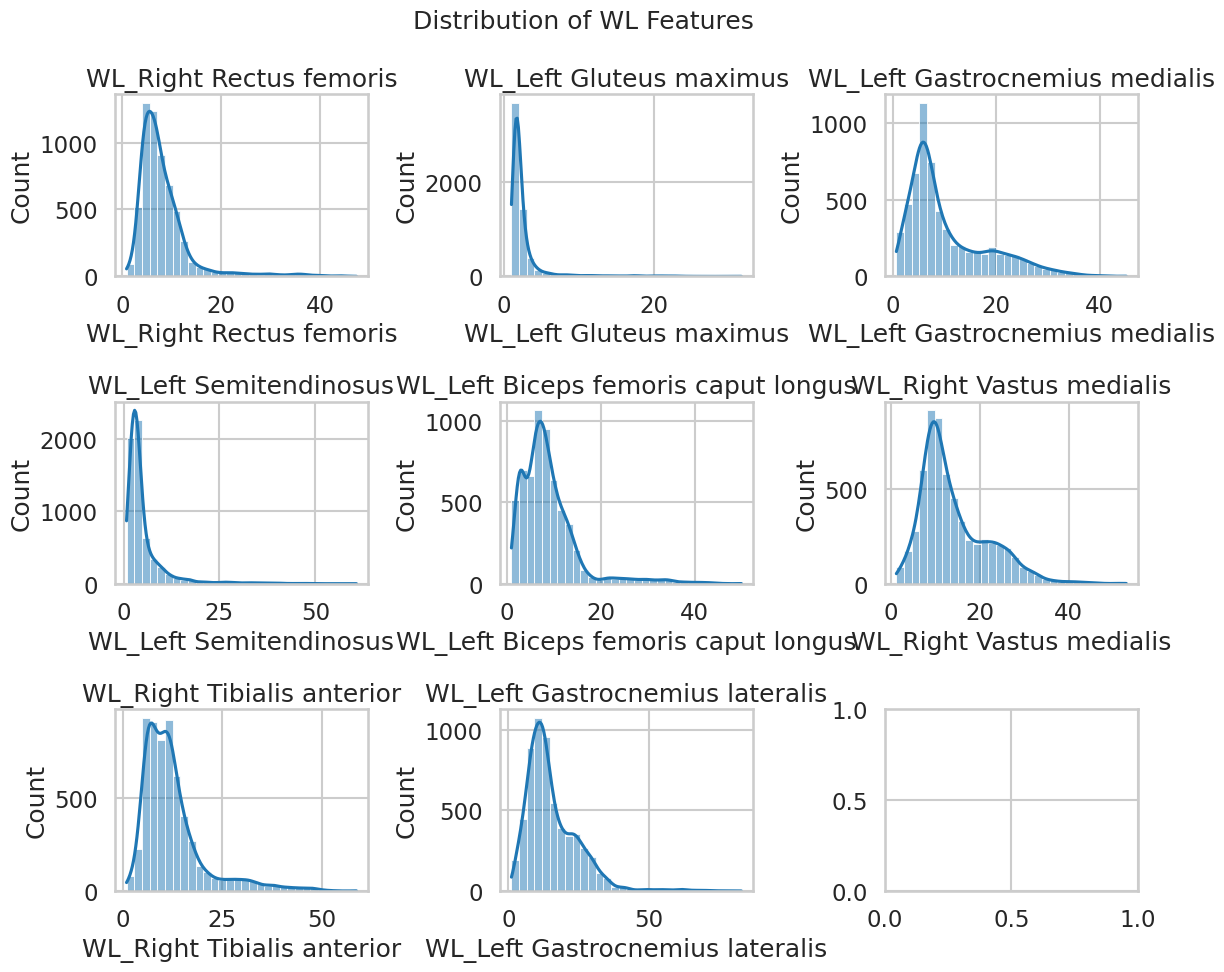

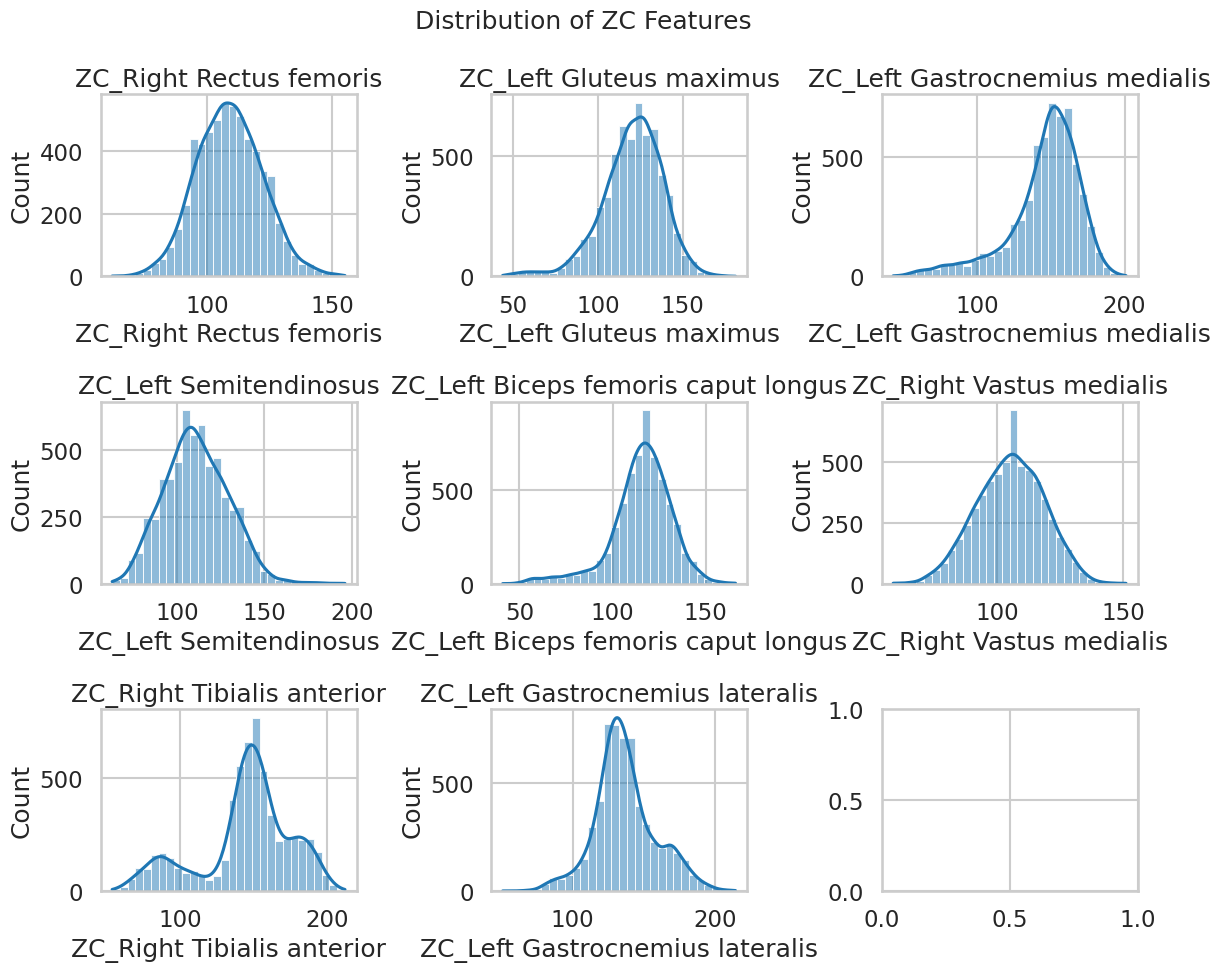

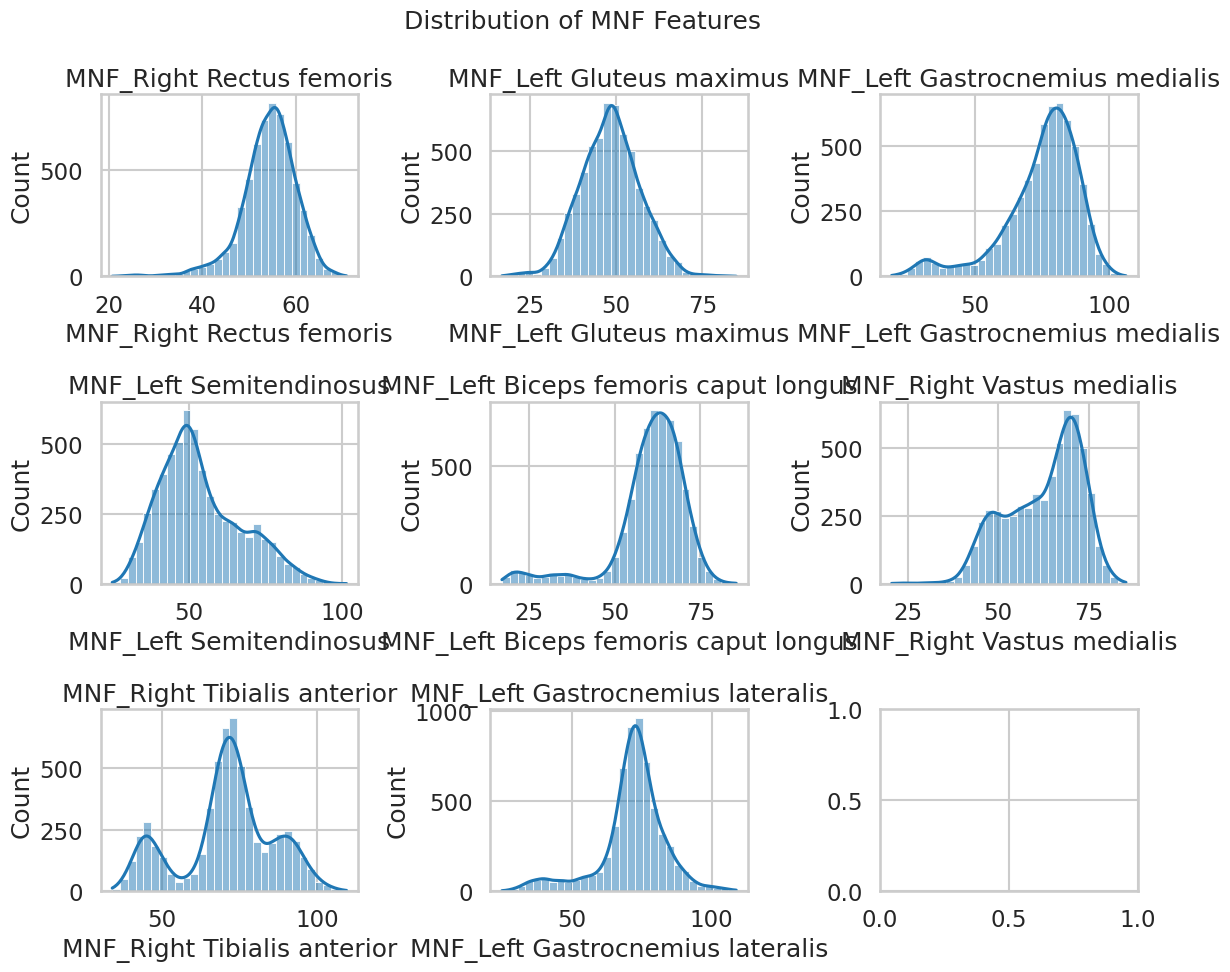

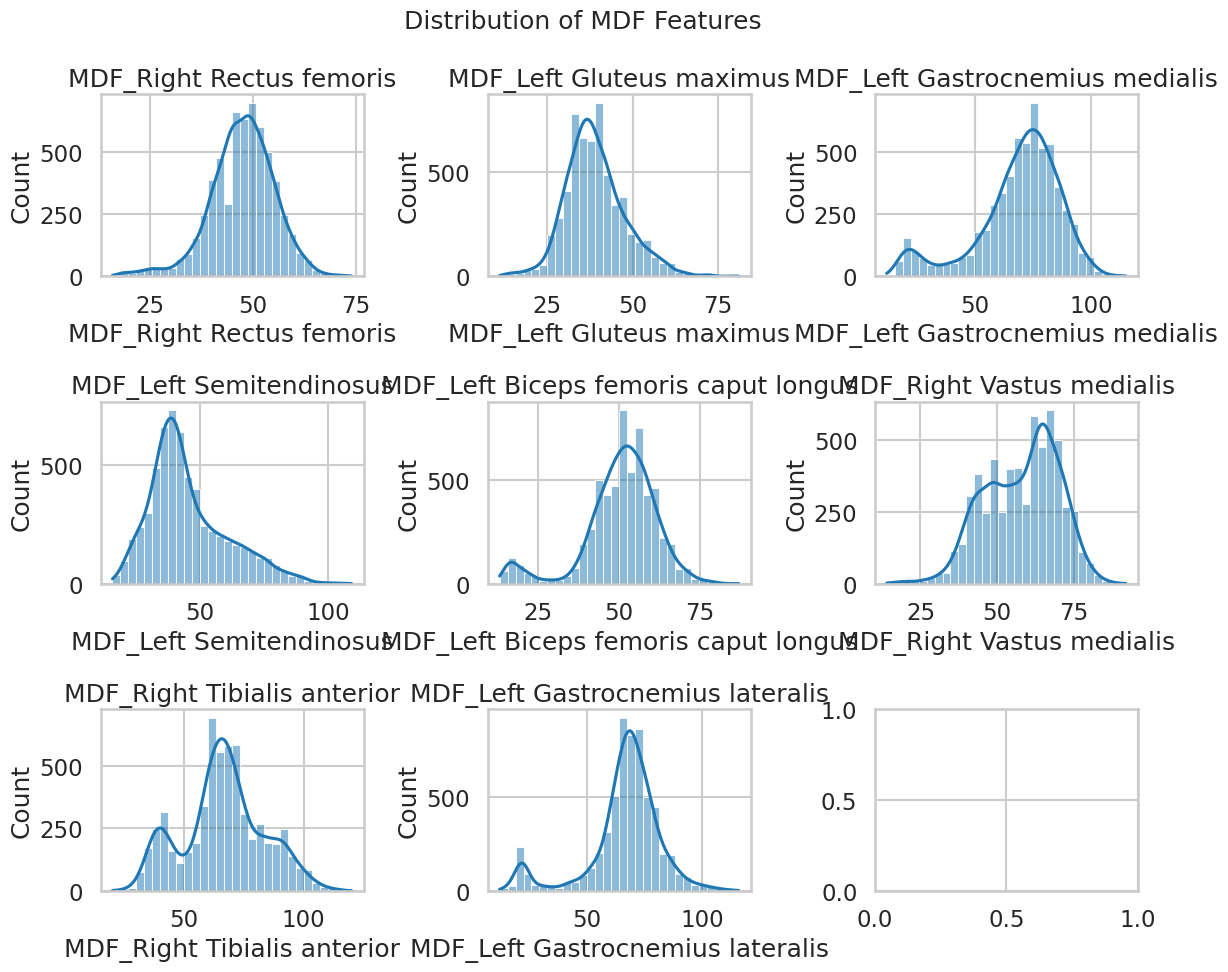

In [38]:
feature_types = ["RMS", "MAV", "VAR", "WL", "ZC", "MNF", "MDF"]
for feature in feature_types:
    
    cols = [col for col in features_df.columns if col.startswith(feature)]
    
    fig, axes = plt.subplots(3, 3, figsize=(12,10))
    
    for i, col in enumerate(cols):
        
        ax = axes.flatten()[i]
        
        sns.histplot(
            features_df[col],
            bins=30,
            kde=True,
            ax=ax
        )
        
        ax.set_title(col)
    
    plt.suptitle(f"Distribution of {feature} Features", fontsize=18)
    plt.tight_layout()
    plt.show()

### Correlation matrix

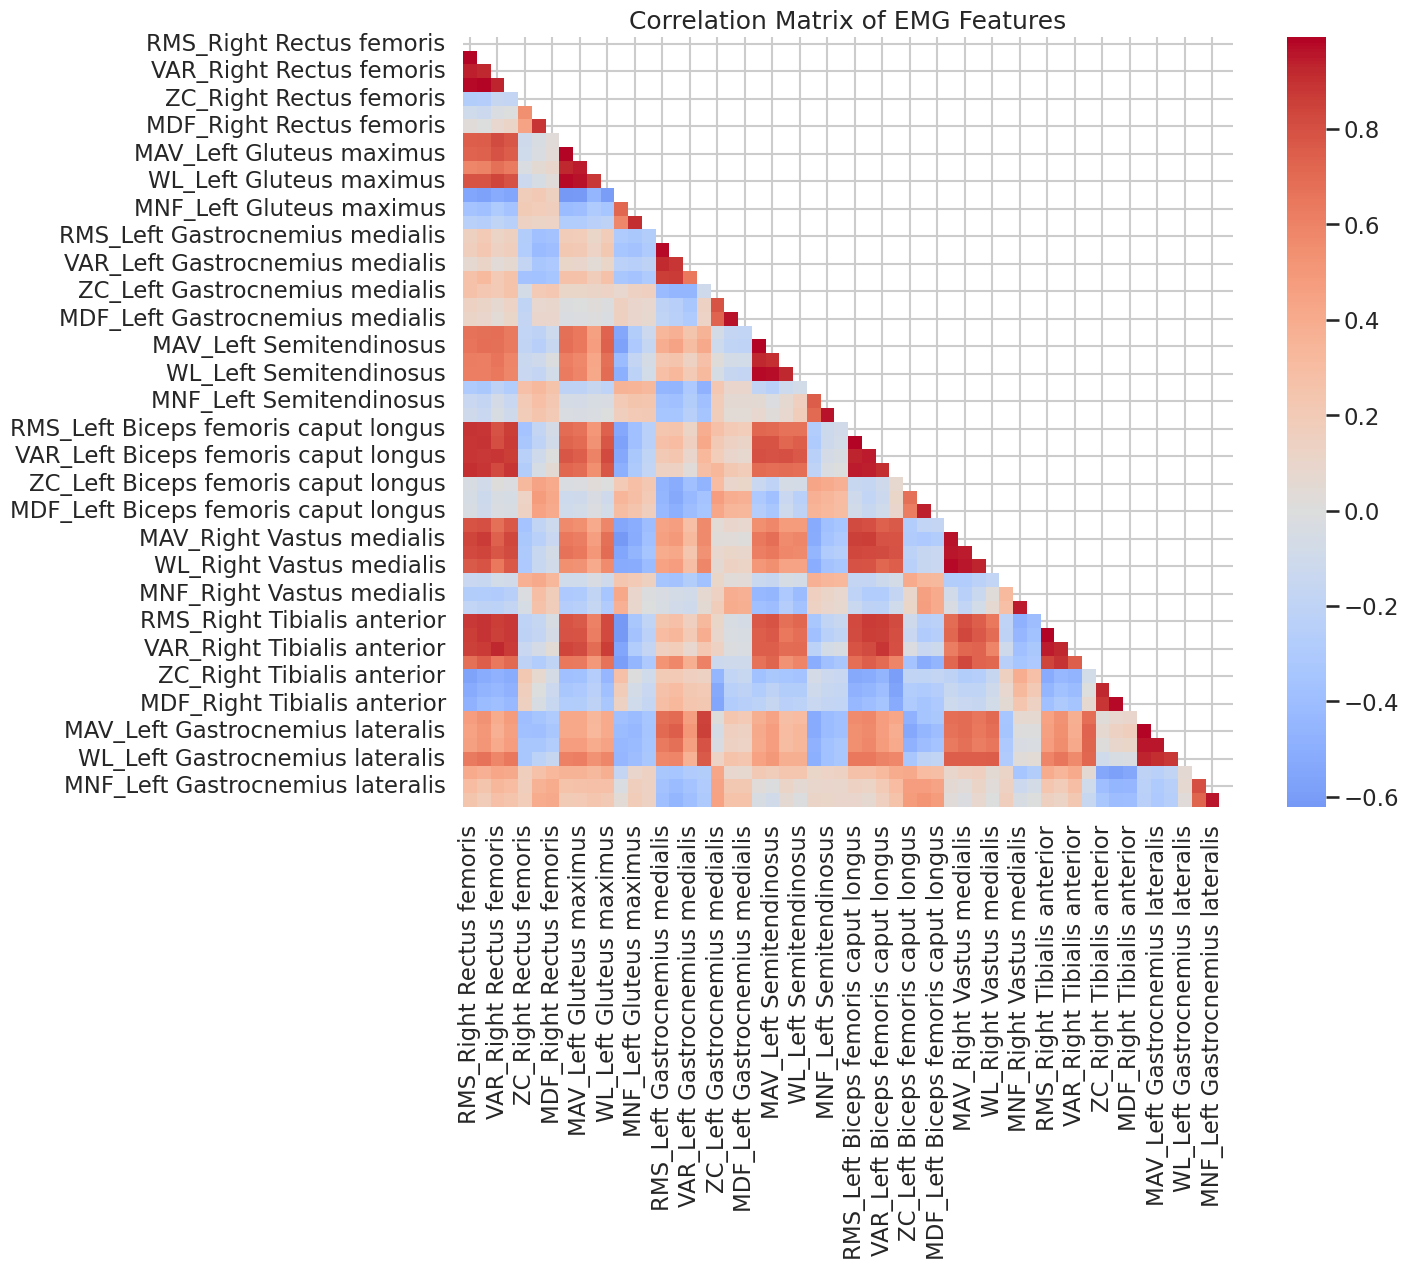

In [39]:
corr_matrix = features_df.drop(columns="Target").corr()

plt.figure(figsize=(14,10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of EMG Features")
plt.show()

The correlation matrix reveals strong positive relationships among several time-domain features such as RMS, MAV, and variance, indicating that these metrics capture similar properties of the EMG signal amplitude. In contrast, frequency-domain features such as MNF and MDF show weaker correlations with time-domain features, suggesting that they provide complementary information about the muscle activity. Additionally, features extracted from the same muscle tend to exhibit stronger correlations, reflecting shared physiological patterns. These observations indicate that while some redundancy exists among features, the combination of time-domain and frequency-domain characteristics provides a richer representation of the EMG signals.

### BoxPlot per Class

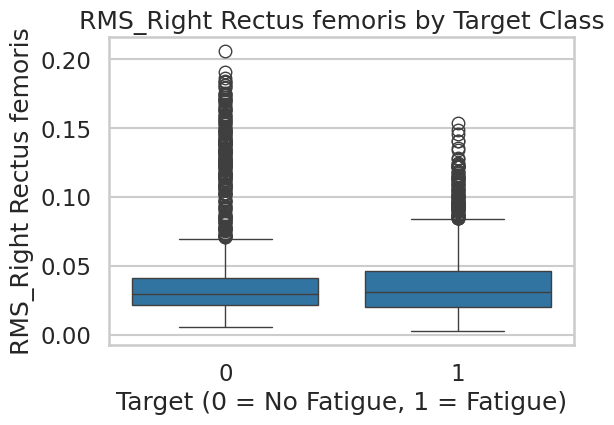

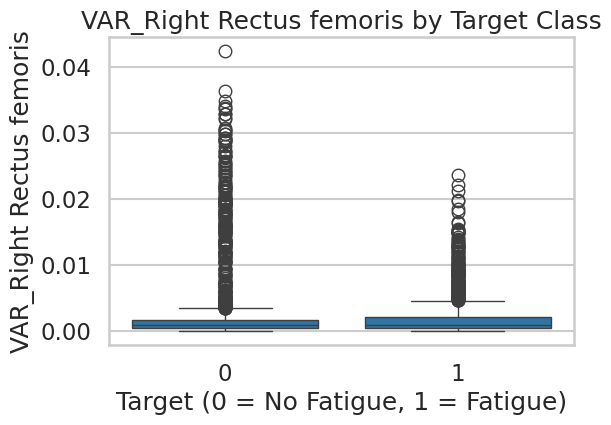

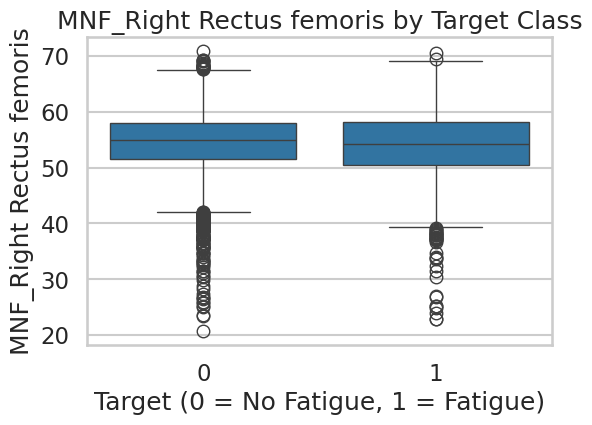

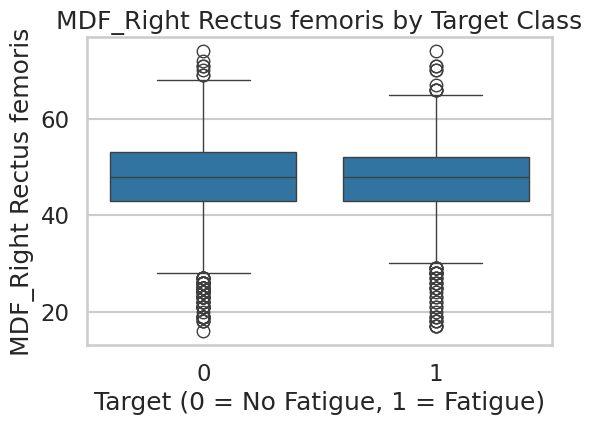

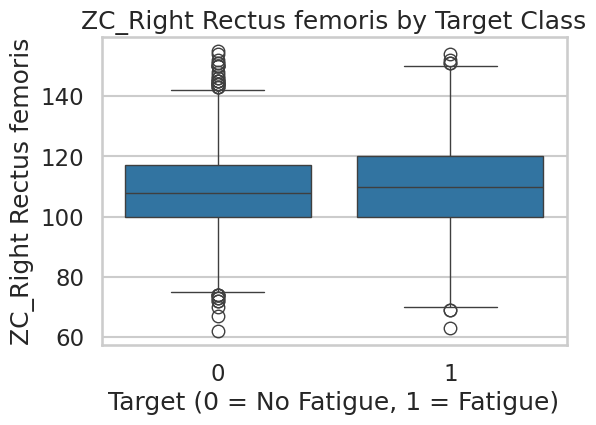

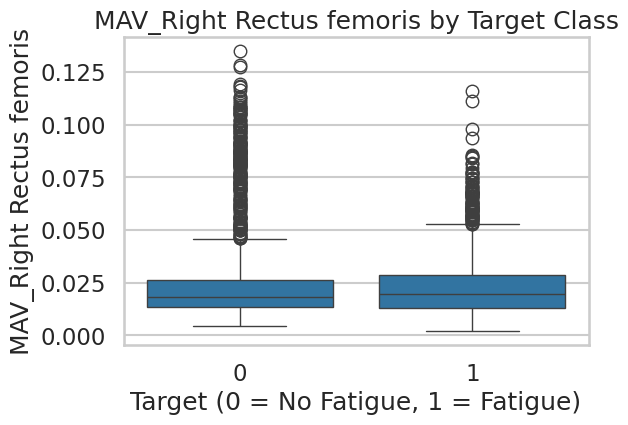

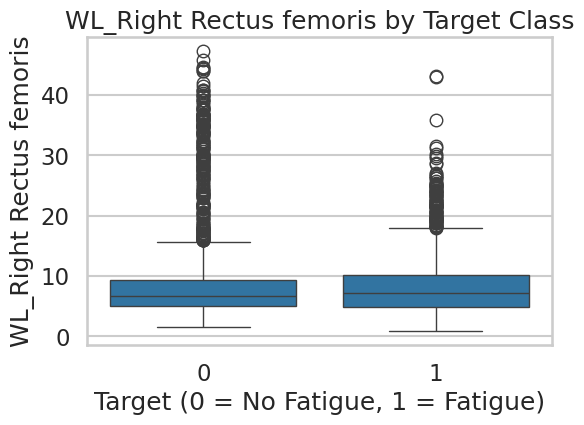

In [40]:
features_to_plot = [
    "RMS_Right Rectus femoris",
    "VAR_Right Rectus femoris",
    "MNF_Right Rectus femoris",
    "MDF_Right Rectus femoris",
    "ZC_Right Rectus femoris",
    "MAV_Right Rectus femoris",
    "WL_Right Rectus femoris"
]



for feature in features_to_plot:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=features_df,
        x="Target",
        y=feature
    )

    plt.title(f"{feature} by Target Class")
    plt.xlabel("Target (0 = No Fatigue, 1 = Fatigue)")
    plt.ylabel(feature)

    plt.show()

The main conclusion from these graphs is that there is no significant difference between the value ranges for the two classes, 0 (No Fatigue) and 1 (Fatigue). However, we hypothesize that when these features are analyzed together, they may reveal important patterns that can help distinguish between the two classes.

### Cluster map

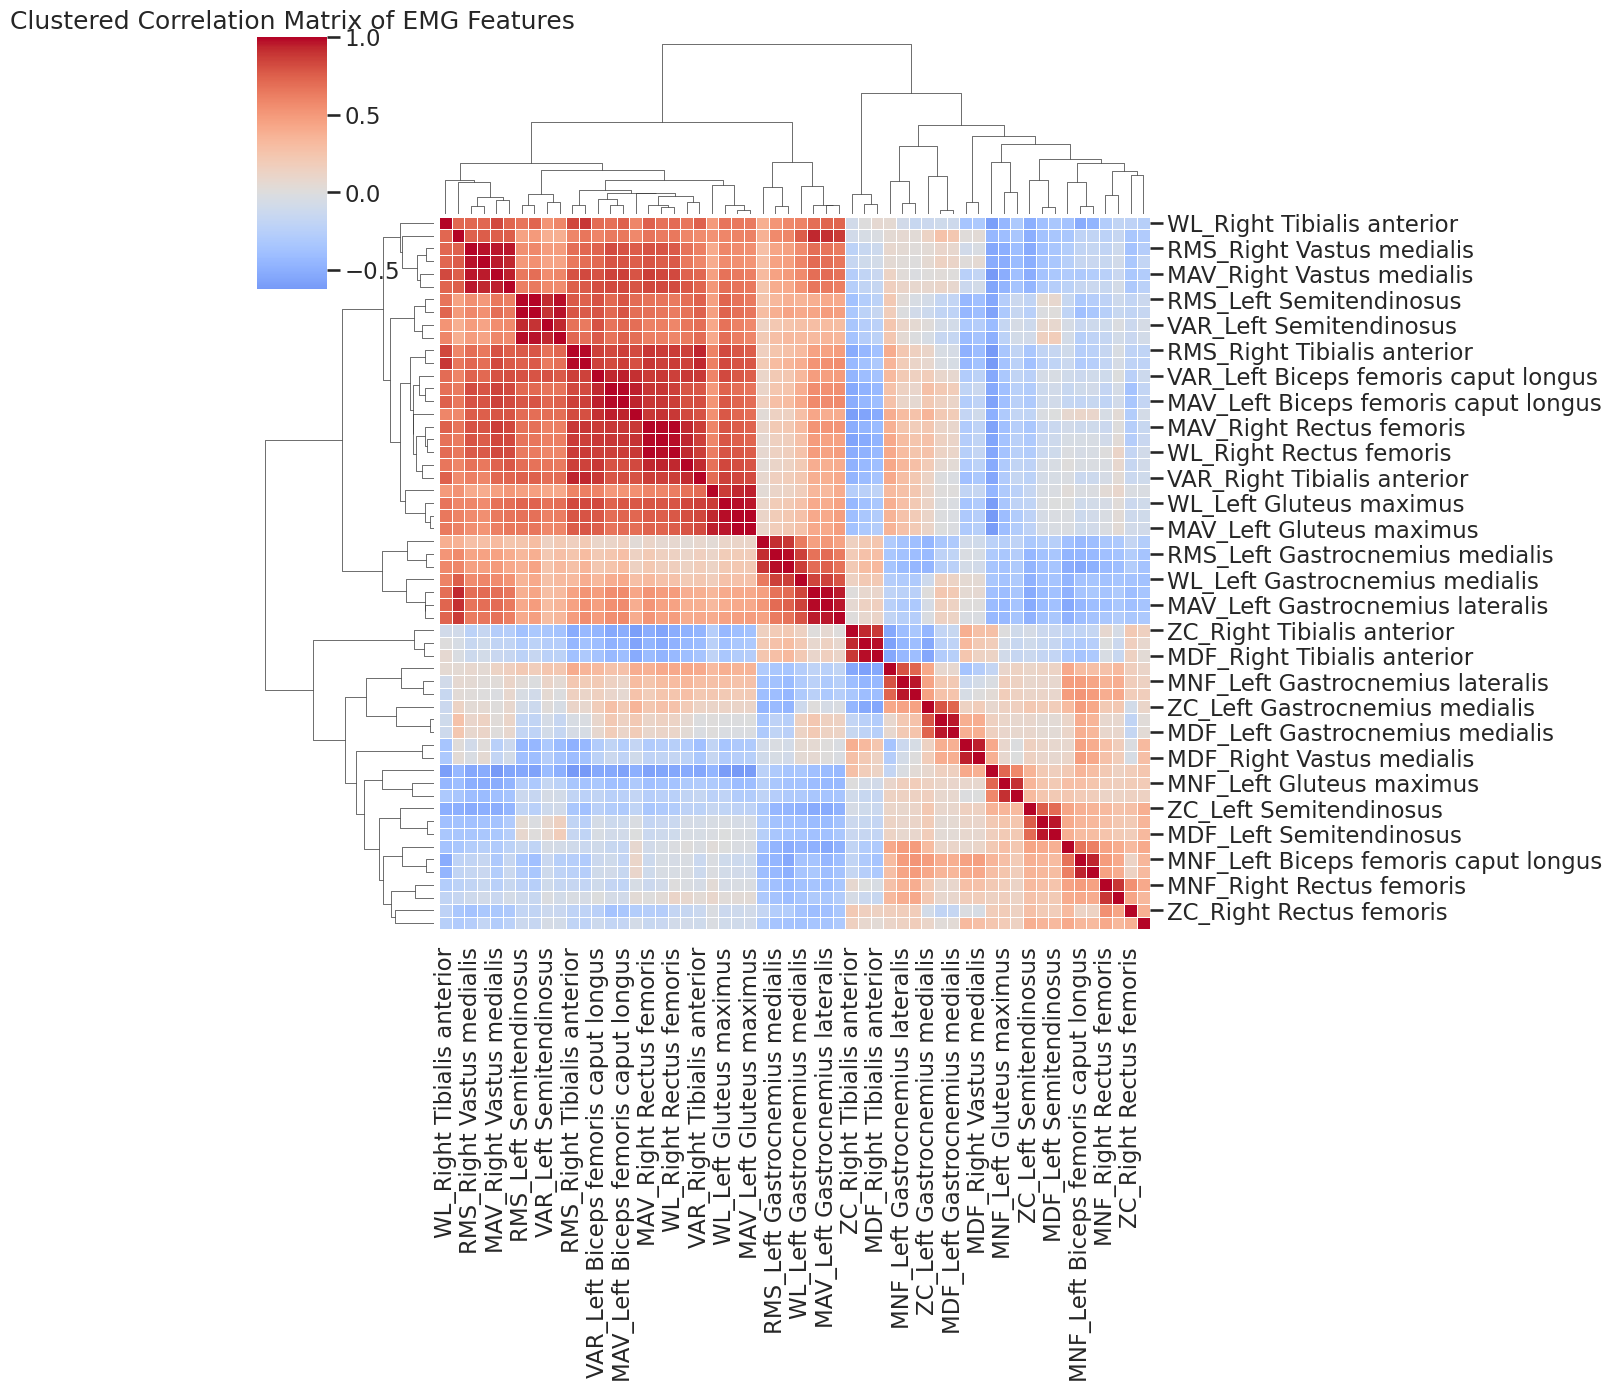

In [41]:
import scipy
sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    figsize=(14,14),
    linewidths=0.5
)

plt.title("Clustered Correlation Matrix of EMG Features")
plt.show()

The clustered correlation matrix shows that several time-domain features, such as RMS, MAV, variance, and waveform length, are highly correlated with each other. This suggests that these features capture similar aspects of the EMG signal amplitude. In contrast, frequency-domain features such as MNF and MDF form separate clusters, indicating that they provide different information about the signal. Overall, although some redundancy exists among time-domain features, the combination of time-domain and frequency-domain characteristics offers a more complete representation of the EMG signals for the classification task.

### Class balance analysis

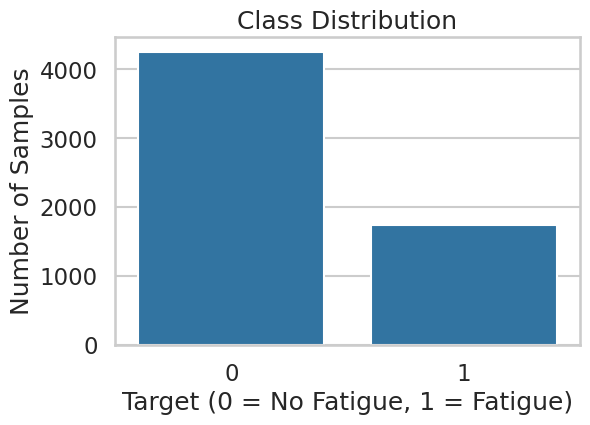

In [42]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=features_df,
    x="Target"
)

plt.title("Class Distribution")
plt.xlabel("Target (0 = No Fatigue, 1 = Fatigue)")
plt.ylabel("Number of Samples")

plt.show()

The class distribution analysis shows that the dataset is imbalanced, with a significantly higher number of samples belonging to the non-fatigue class compared to the fatigue class. This imbalance may influence the performance of classification models, as they could become biased toward predicting the majority class. Therefore, it may be important to consider techniques such as class weighting, resampling, or evaluation metrics that account for class imbalance.

## Signals in time

### Small dataset

In [43]:
samples = 5000
signal_segment = df.iloc[:samples]

### Graph Signals

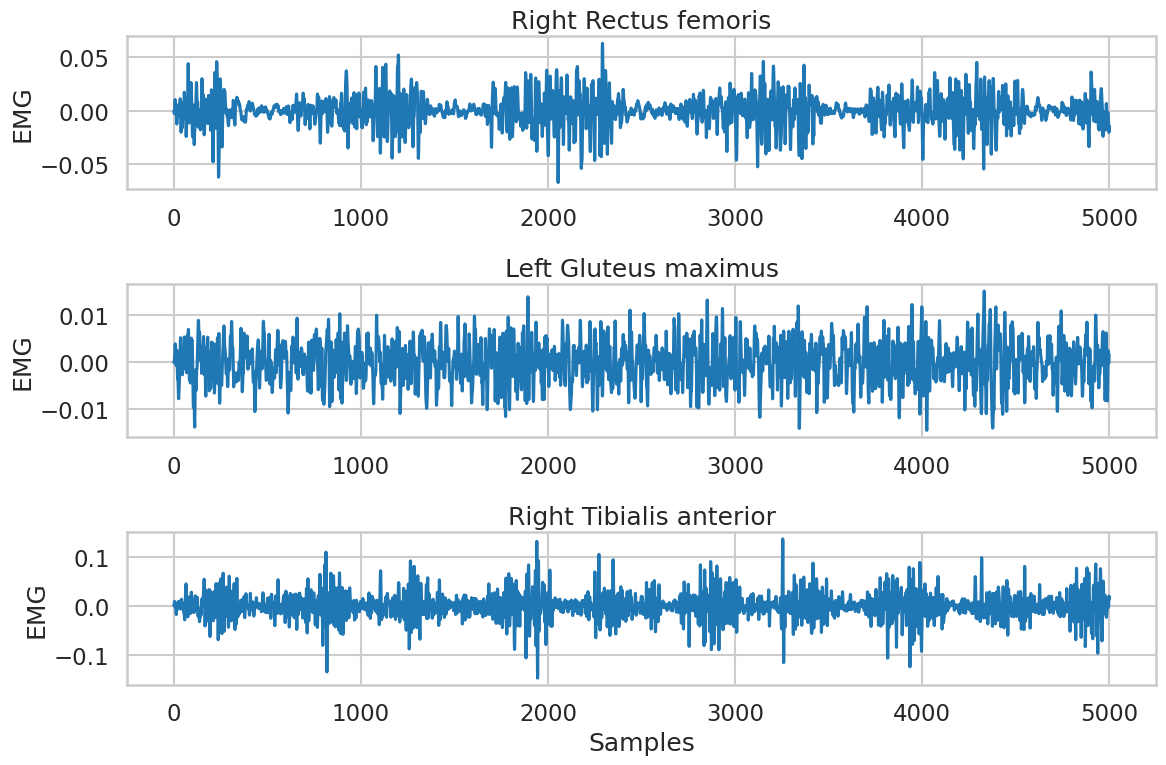

In [44]:
muscles = [
    "Right Rectus femoris",
    "Left Gluteus maximus",
    "Right Tibialis anterior"
]

fig, axes = plt.subplots(len(muscles), 1, figsize=(12,8))

for i, muscle in enumerate(muscles):

    axes[i].plot(signal_segment[muscle])
    axes[i].set_title(muscle)
    axes[i].set_ylabel("EMG")

axes[-1].set_xlabel("Samples")

plt.tight_layout()
plt.show()

The plotted EMG signals show oscillatory patterns typical of muscle activity recordings, with amplitudes fluctuating around zero. Noticeable variations in signal amplitude can be observed over time, suggesting changes in the level of muscle activation during the cycling exercise. Additionally, different muscles exhibit distinct signal patterns, indicating that each EMG channel captures specific aspects of muscular activity. These observations suggest that muscle fatigue cannot be directly identified from the raw signals alone, but meaningful patterns may emerge when analyzing the signals through feature extraction techniques in both the time and frequency domains. This highlights the importance of combining information from multiple muscles and features to effectively detect fatigue states.

# 4. Data Preprocessing

## Get Features of datafram

In [ ]:
X = features_df.drop(columns=['Target'])
Y = features_df['Target']



## Pipeline Pre-Proccesing

In [50]:
numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, X.columns),
    ],
)

## Split data into train, validate y test 

In [55]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


y_train.value_counts(normalize=True), y_test.value_counts(normalize=True), y_val.value_counts(normalize=True)

(Target
 0    0.708871
 1    0.291129
 Name: proportion, dtype: float64,
 Target
 0    0.708819
 1    0.291181
 Name: proportion, dtype: float64,
 Target
 0    0.708333
 1    0.291667
 Name: proportion, dtype: float64)

Question for the professor: Since all the features are numerical, is it unnecessary to separate them into categorical and numerical features?

## Note

Because the windows are generated before splitting the dataset, some overlap between training and testing windows may occur. This could introduce a small amount of data leakage, as adjacent windows may contain similar signal segments. However, according with our short investigation, this is normal when we talk about biological signals

# 5. Training and model Comparison